In [26]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [27]:
import ml_utils as mlu
from ml_utils import *
# [x for x in dir(mlu) if not x.startswith("_")]
print("Functions available under data_cleaning package are: ", [x for x in dir(mlu.data_cleaning) if not x.startswith("_")])
print("Functions available under feature_engineering package are: ", [x for x in dir(mlu.feature_engineering) if not x.startswith("_")])
print("Functions available under outliers package are: ", [x for x in dir(mlu.outliers) if not x.startswith("_")])
print("Functions available under scalar package are: ", [x for x in dir(mlu.scalar) if not x.startswith("_")])

Functions available under data_cleaning package are:  ['KNNImputer', 'SimpleImputer', 'categorical_imputer', 'clean_column_names', 'drop_columns', 'drop_null_rows', 'find_duplicates', 'get_column_types', 'missing_values', 'numerical_imputer', 'pickle', 'remove_constant_columns', 'remove_duplicates']
Functions available under feature_engineering package are:  ['LabelEncoder', 'label_encode', 'pickle', 'target_label_encode']
Functions available under outliers package are:  ['detect_outliers', 'os', 'pd', 'pickle', 'replace_outliers']
Functions available under scalar package are:  ['StandardScaler', 'scale_features']


In [28]:
# Download latest version
path = kagglehub.dataset_download("fedesoriano/company-bankruptcy-prediction")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\vikram.vadhirajan\.cache\kagglehub\datasets\fedesoriano\company-bankruptcy-prediction\versions\2


In [29]:
df=pd.read_csv(path+"\\"+"data.csv" )
df

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


In [30]:
df.head()
Target="Bankrupt?"

In [31]:
mlu.find_duplicates(df).sum().sort_values(ascending=False)

Bankrupt?                                                   0.0
 ROA(C) before interest and depreciation before interest    0.0
 Total expense/Assets                                       0.0
 Total income/Total expense                                 0.0
 Retained Earnings to Total Assets                          0.0
                                                           ... 
 Total Asset Growth Rate                                    0.0
 Continuous Net Profit Growth Rate                          0.0
 Regular Net Profit Growth Rate                             0.0
 After-tax Net Profit Growth Rate                           0.0
 Equity to Liability                                        0.0
Length: 96, dtype: float64

In [32]:
mlu.missing_values(df)

Bankrupt?                                                   0.0
 ROA(C) before interest and depreciation before interest    0.0
 Total expense/Assets                                       0.0
 Total income/Total expense                                 0.0
 Retained Earnings to Total Assets                          0.0
                                                           ... 
 Total Asset Growth Rate                                    0.0
 Continuous Net Profit Growth Rate                          0.0
 Regular Net Profit Growth Rate                             0.0
 After-tax Net Profit Growth Rate                           0.0
 Equity to Liability                                        0.0
Length: 96, dtype: float64

In [33]:
num,cat=mlu.get_column_types(df)
print(f"The categorical columns are {cat}")
print(f"The numeric columns are {num}")

The categorical columns are []
The numeric columns are ['Bankrupt?', ' ROA(C) before interest and depreciation before interest', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Operating Gross Margin', ' Realized Sales Gross Margin', ' Operating Profit Rate', ' Pre-tax net Interest Rate', ' After-tax net Interest Rate', ' Non-industry income and expenditure/revenue', ' Continuous interest rate (after tax)', ' Operating Expense Rate', ' Research and development expense rate', ' Cash flow rate', ' Interest-bearing debt interest rate', ' Tax rate (A)', ' Net Value Per Share (B)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons', ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)', ' Operating Profit Per Share (Yuan ¥)', ' Per Share Net profit before tax (Yuan ¥)', ' Realized Sales Gross Profit Growth Rate', ' Operating Profit Growth Rate', ' After-tax Net Profit Growth Rate', ' Regular N

In [34]:
mlu.missing_values(df)

Bankrupt?                                                   0.0
 ROA(C) before interest and depreciation before interest    0.0
 Total expense/Assets                                       0.0
 Total income/Total expense                                 0.0
 Retained Earnings to Total Assets                          0.0
                                                           ... 
 Total Asset Growth Rate                                    0.0
 Continuous Net Profit Growth Rate                          0.0
 Regular Net Profit Growth Rate                             0.0
 After-tax Net Profit Growth Rate                           0.0
 Equity to Liability                                        0.0
Length: 96, dtype: float64

In [35]:
mlu.detect_outliers(df,num)

[{'column': 'Bankrupt?', 'outlier_count': 220},
 {'column': ' ROA(C) before interest and depreciation before interest',
  'outlier_count': 391},
 {'column': ' ROA(A) before interest and % after tax', 'outlier_count': 561},
 {'column': ' ROA(B) before interest and depreciation after tax',
  'outlier_count': 432},
 {'column': ' Operating Gross Margin', 'outlier_count': 320},
 {'column': ' Realized Sales Gross Margin', 'outlier_count': 318},
 {'column': ' Operating Profit Rate', 'outlier_count': 716},
 {'column': ' Pre-tax net Interest Rate', 'outlier_count': 773},
 {'column': ' After-tax net Interest Rate', 'outlier_count': 867},
 {'column': ' Non-industry income and expenditure/revenue',
  'outlier_count': 1094},
 {'column': ' Continuous interest rate (after tax)', 'outlier_count': 806},
 {'column': ' Operating Expense Rate', 'outlier_count': 0},
 {'column': ' Research and development expense rate', 'outlier_count': 182},
 {'column': ' Cash flow rate', 'outlier_count': 576},
 {'column':

In [36]:
mlu.replace_outliers(df,num)
mlu.detect_outliers(df,num)

[{'column': 'Bankrupt?', 'outlier_count': 0},
 {'column': ' ROA(C) before interest and depreciation before interest',
  'outlier_count': 0},
 {'column': ' ROA(A) before interest and % after tax', 'outlier_count': 0},
 {'column': ' ROA(B) before interest and depreciation after tax',
  'outlier_count': 0},
 {'column': ' Operating Gross Margin', 'outlier_count': 0},
 {'column': ' Realized Sales Gross Margin', 'outlier_count': 0},
 {'column': ' Operating Profit Rate', 'outlier_count': 0},
 {'column': ' Pre-tax net Interest Rate', 'outlier_count': 0},
 {'column': ' After-tax net Interest Rate', 'outlier_count': 0},
 {'column': ' Non-industry income and expenditure/revenue',
  'outlier_count': 0},
 {'column': ' Continuous interest rate (after tax)', 'outlier_count': 0},
 {'column': ' Operating Expense Rate', 'outlier_count': 0},
 {'column': ' Research and development expense rate', 'outlier_count': 0},
 {'column': ' Cash flow rate', 'outlier_count': 0},
 {'column': ' Interest-bearing debt in

In [37]:
num.remove(Target)

In [38]:
mlu.scale_features(df,num)

(      Bankrupt?   ROA(C) before interest and depreciation before interest  \
 0             0                                          -2.286227          
 1             0                                          -0.803746          
 2             0                                          -1.546170          
 3             0                                          -2.055640          
 4             0                                          -0.789541          
 ...         ...                                                ...          
 6814          0                                          -0.232723          
 6815          0                                          -0.592571          
 6816          0                                          -0.639920          
 6817          0                                           0.011595          
 6818          0                                          -0.245033          
 
        ROA(A) before interest and % after tax  \
 0          

In [39]:
df

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,-2.286227,-2.104191,-2.240903,-0.592802,-0.592542,-0.485462,-1.968692,-1.923830,-1.924295,...,-2.086986,1.437549,-1.826713,-0.593000,-2.094433,2.388616,-1.722778,-1.773674,0.0,-1.079480
1,0,-0.803746,-0.445120,-0.755089,0.223183,0.225966,-0.678229,-0.463016,-0.489330,0.245699,...,-0.532699,1.202013,-0.430231,0.223464,-0.530164,1.165743,1.808522,1.837215,0.0,-0.896730
2,0,-1.546170,-1.227716,-1.638963,-0.593472,-0.601278,-1.413812,-1.968692,-1.923830,-1.924295,...,-1.276498,2.120807,-0.088158,-0.593367,-2.083372,2.388616,-1.722778,-1.773674,0.0,-1.079253
3,0,-2.055640,-2.104191,-1.928618,-2.258269,-2.263159,-2.045579,-1.968692,-1.923830,-1.426231,...,-2.086986,-0.130777,-1.736811,-2.258388,-2.094433,0.569877,-1.082375,-1.208597,0.0,-0.762040
4,0,-0.789541,-0.440767,-0.644338,-0.841349,-0.841858,-0.452855,-0.537877,-0.470291,-0.412526,...,-0.542841,0.033518,-0.667039,-0.841360,-0.528473,-0.329593,-1.722778,1.837215,0.0,-0.275848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,-0.232723,-0.420086,-0.227959,-0.314108,-0.312314,-0.295572,-0.310356,-0.296463,-0.127361,...,-0.365750,-0.863289,-0.488475,-0.314010,-0.340718,-0.023426,1.577327,1.229938,0.0,-0.512443
6815,0,-0.592571,-0.444032,-0.607066,-0.885565,-0.886211,-0.294613,-0.281733,-0.320468,-0.051186,...,-0.372190,-0.470685,0.073968,-0.885556,-0.366590,-0.436622,1.174413,0.950967,0.0,-0.157826
6816,0,-0.639920,-0.534373,-0.677350,0.242611,0.223950,-0.358869,-0.352925,-0.386688,-0.111735,...,-0.443239,-0.239220,0.481153,0.242433,-0.448008,-1.093818,-0.398541,-0.419590,0.0,2.254397
6817,0,0.011595,-0.011917,-0.012847,0.001434,0.003531,0.382468,0.171842,0.138109,-0.225020,...,0.062659,-0.239927,0.122288,0.001240,0.011567,-0.600666,-0.175056,-0.191466,0.0,0.084079


In [47]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
data_pca=pca.fit_transform(df)

In [48]:
data_pca

array([[-12.36086298,  -1.62410745,  -1.74501951],
       [ -4.44082931,  -1.36895716,  -4.98159377],
       [ -7.55493776,   0.79838424,   0.99990759],
       ...,
       [  2.62102414,   6.12273181,   1.66670849],
       [  3.5880254 ,  -0.13717125,  -1.05447366],
       [  4.97320593,   5.57973774,   1.64234239]])

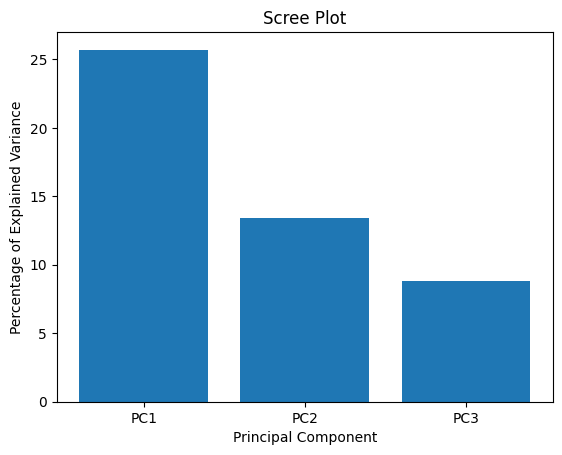

In [49]:
per_var= np.round(pca.explained_variance_ratio_*100, decimals=1)
labels = [f"PC{i}" for i in range(1, len(per_var)+1)]
plt.bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
plt.ylabel("Percentage of Explained Variance")
plt.xlabel("Principal Component")
plt.title("Scree Plot")
plt.show()

In [50]:
pca.explained_variance_

array([23.93671192, 12.49231688,  8.17779769])